In [761]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [762]:
df = pd.read_csv('housing.csv')

In [763]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [764]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


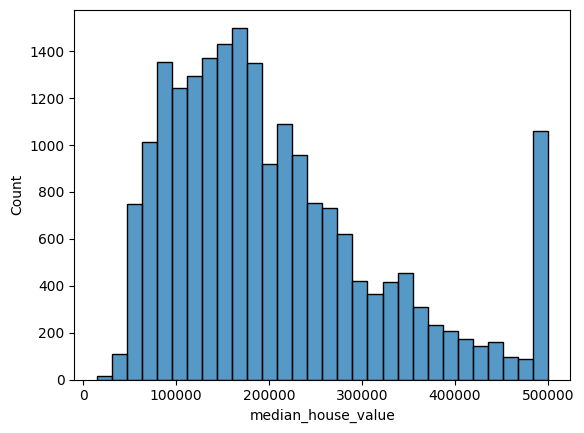

In [765]:
sns.histplot(df['median_house_value'], bins=30)
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

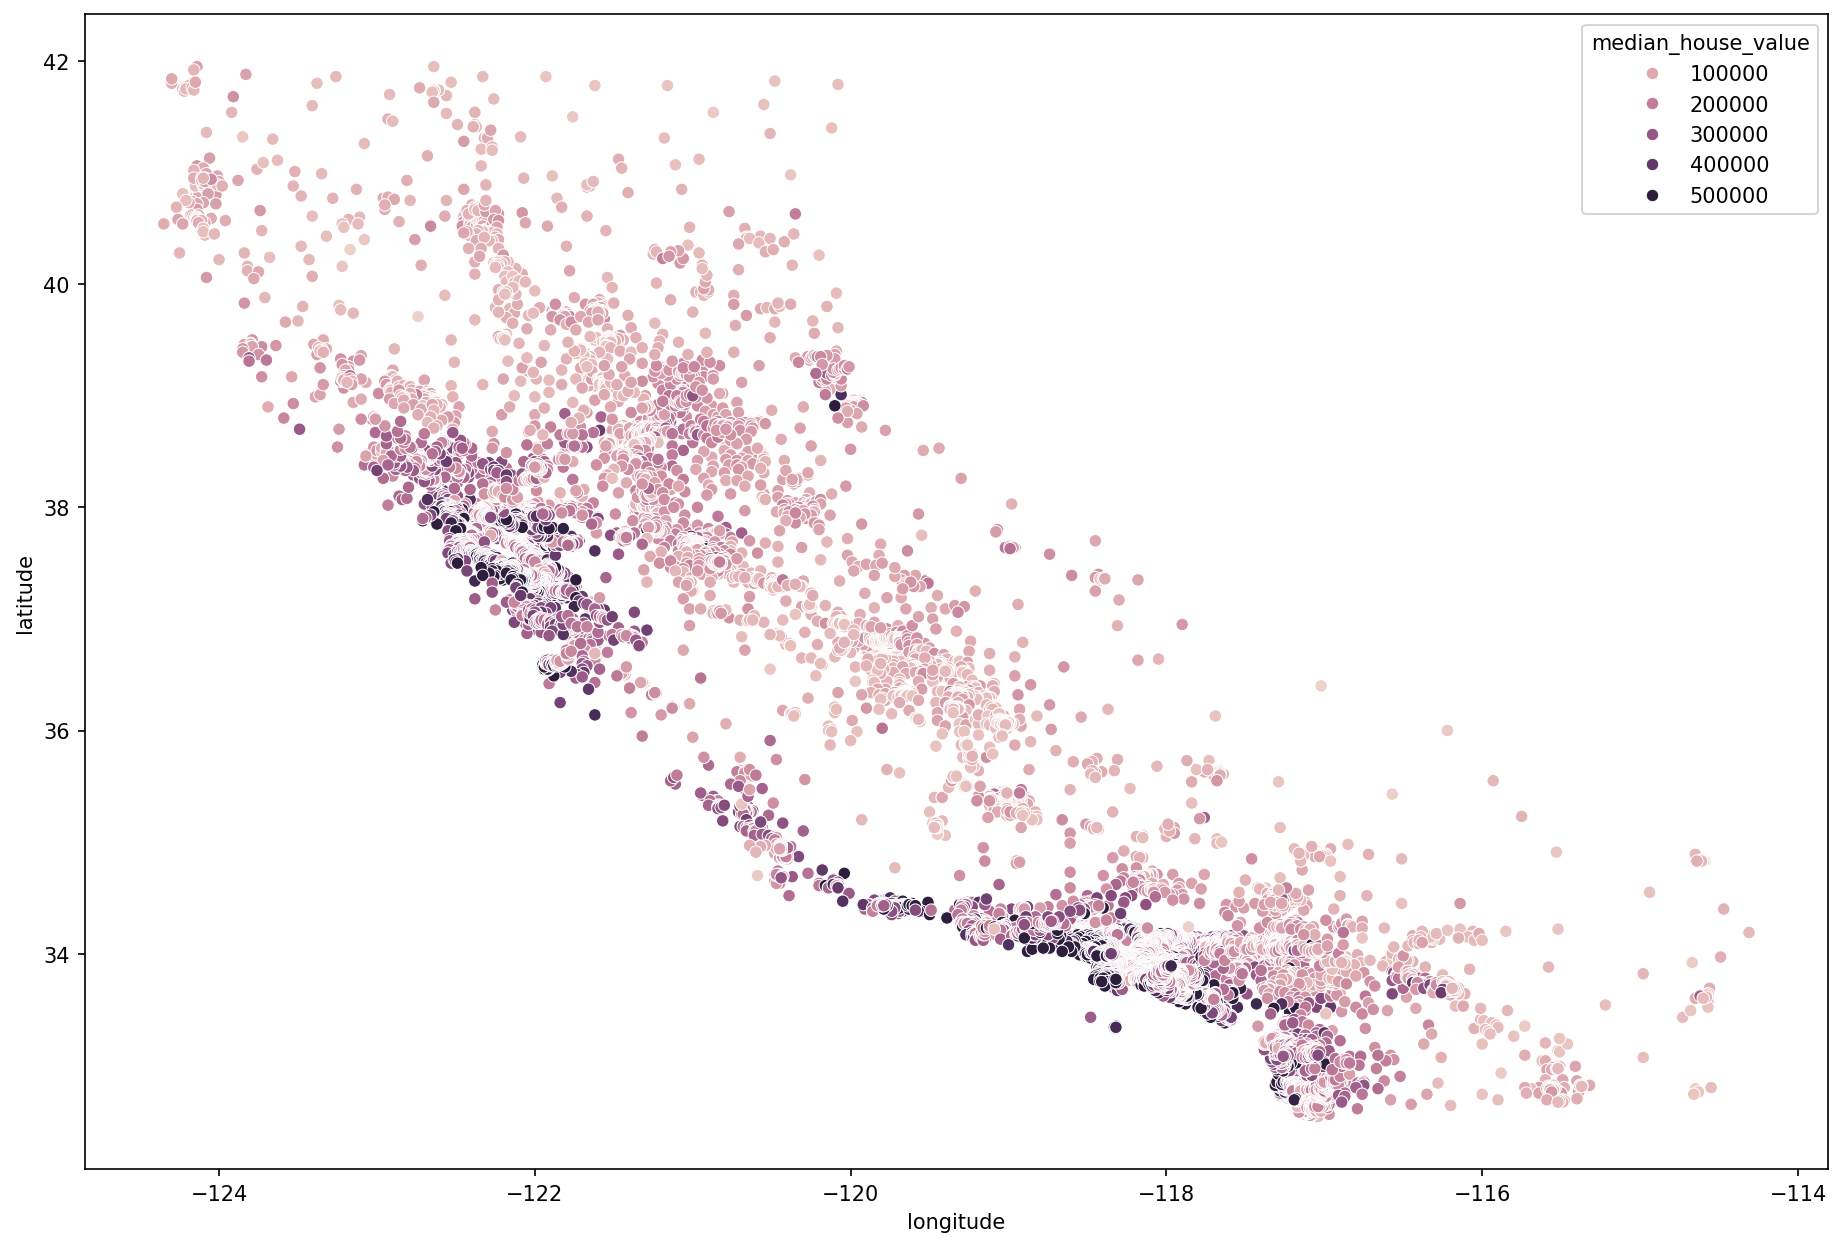

In [766]:

plt.figure(figsize=(15,10),dpi=150)
sns.scatterplot(data=df,x = "longitude" , y = "latitude",hue='median_house_value')

In [767]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [768]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [769]:
207/df.shape[0] # 1% of dataset is missing, might be minimal data loss

0.01002906976744186

<Axes: xlabel='total_bedrooms', ylabel='median_house_value'>

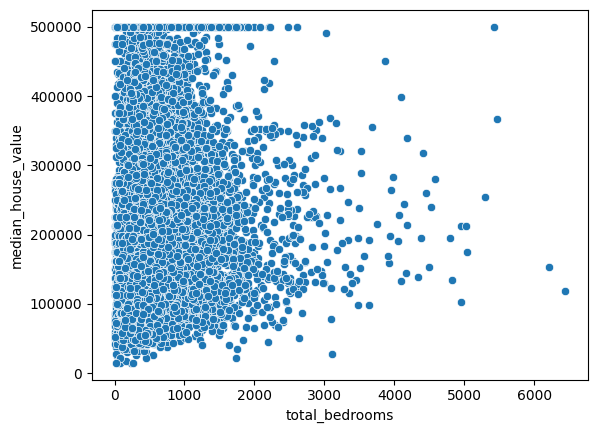

In [770]:
sns.scatterplot(df, x='total_bedrooms',y='median_house_value',)

In [771]:

df = df.dropna()

In [772]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [773]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Add distance_to_coast to capture geographical patterns
df['distance_to_coast'] = np.abs(df['longitude'] - (-122))
# Adding more features to improve performance
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['lat_lon_interaction'] = df['latitude'] * df['longitude']
X = pd.get_dummies(df.drop('median_house_value', axis=1), columns=['ocean_proximity'], drop_first=True)
# drop_first to avoid multicollinearity
X = X.values
y = df['median_house_value'].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

In [774]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20433 non-null  float64
 1   latitude                  20433 non-null  float64
 2   housing_median_age        20433 non-null  float64
 3   total_rooms               20433 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20433 non-null  float64
 6   households                20433 non-null  float64
 7   median_income             20433 non-null  float64
 8   median_house_value        20433 non-null  float64
 9   ocean_proximity           20433 non-null  object 
 10  distance_to_coast         20433 non-null  float64
 11  rooms_per_household       20433 non-null  float64
 12  bedrooms_per_room         20433 non-null  float64
 13  population_per_household  20433 non-null  float64
 14  lat_lon_int

In [775]:
X.shape

(20433, 17)

In [776]:
y.shape

(20433,)

In [777]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [778]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

In [779]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [780]:
X_train_scaled.shape[1]

17

In [781]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
tf.random.set_seed(101)
model = Sequential([
    Dense(128, activation='relu', input_shape=(17,)),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005),
    loss='mse',
    metrics=['mae']
)

c:\Users\johnl\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [782]:
sqrt_n_features = np.sqrt(X_train_scaled.shape[1])
sqrt_n_features

4.123105625617661

In [783]:
min_batch_size = 2**int(sqrt_n_features)
min_batch_size

16

In [784]:
max_batch_size = min_batch_size*sqrt_n_features
max_batch_size

65.96969000988257

In [785]:
batch_size = 64
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, mode='min')
model.fit(
    x=X_train_scaled,
    y=y_train_scaled,
    epochs=100, 
    batch_size=batch_size,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop,lr_schedule]
)

Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5026 - mae: 0.4800 - val_loss: 0.3643 - val_mae: 0.4044 - learning_rate: 0.0050
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - loss: 0.3178 - mae: 0.3882 - val_loss: 0.3100 - val_mae: 0.3807 - learning_rate: 0.0050
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.2771 - mae: 0.3719 - val_loss: 0.3270 - val_mae: 0.3802 - learning_rate: 0.0050
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 0.2609 - mae: 0.3621 - val_loss: 0.3169 - val_mae: 0.3759 - learning_rate: 0.0050
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.2482 - mae: 0.3531 - val_loss: 0.2751 - val_mae: 0.3580 - learning_rate: 0.0050
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2434 - mae: 0.3482 - val_loss: 0.3037 - val_mae: 0.3628 - learning_rate: 0.0050
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 0.2363 - mae: 0.3428 - val_loss: 0.2731 - val_mae: 0.3522 - learning_ra

In [786]:
losses = pd.DataFrame(model.history.history)
losses.head()

,loss,mae,val_loss,val_mae,learning_rate
0,0.396546,0.429884,0.364288,0.404431,0.005
1,0.303976,0.383035,0.309957,0.380680,0.005
2,0.275117,0.370239,0.326960,0.380162,0.005
3,0.261811,0.361576,0.316887,0.375904,0.005
4,0.250535,0.352745,0.275140,0.358046,0.005


<Axes: >

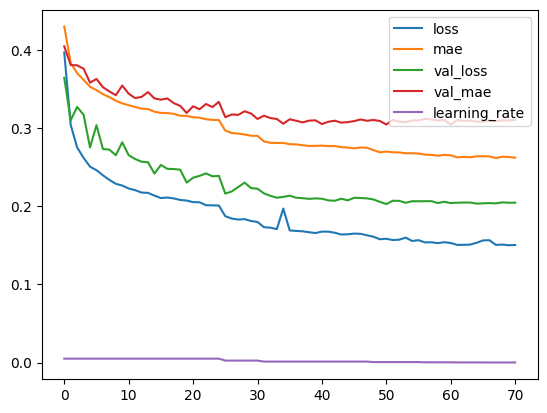

In [787]:
losses.plot()

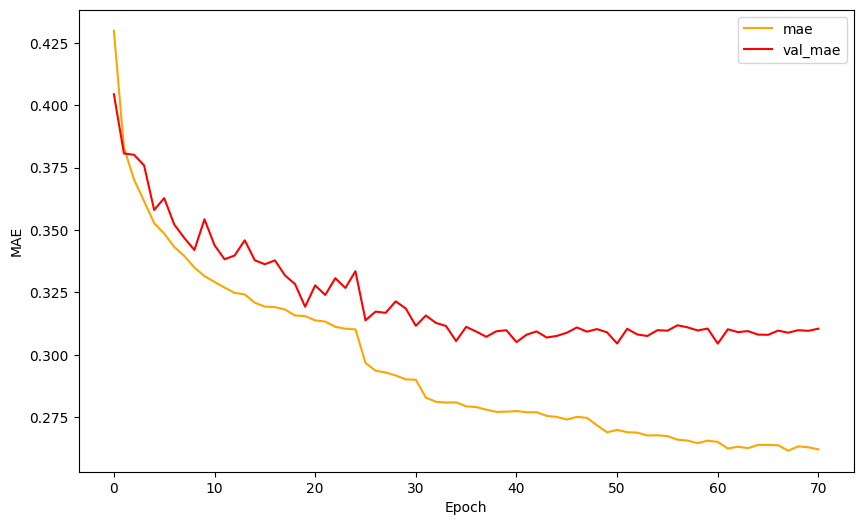

In [788]:
plt.figure(figsize=(10, 6))
plt.plot(losses['mae'], label='mae', color='orange')
plt.plot(losses['val_mae'], label='val_mae', color='red')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [789]:
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_130 (Dense)               │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,628 (104.02 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,315 (52.02 KB)

In [790]:
from sklearn.metrics import r2_score
y_pred_scaled = model.predict(X_test_scaled)
y_pred_dollars = y_scaler.inverse_transform(y_pred_scaled).flatten()
y_test_dollars = y_test


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step


In [791]:


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_clipped_dollars = np.clip(y_pred_dollars, None, 500000)
r2 = r2_score(y_test_dollars, y_pred_clipped_dollars)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_clipped_dollars))
mae_dollars = mean_absolute_error(y_test_dollars, y_pred_clipped_dollars)
print(f"R²: {r2}")
print(f"Dollar-Scale RMSE: {rmse_dollars}")
print(f"Dollar-Scale MAE: {mae_dollars}")

R²: 0.8028372829510402
Dollar-Scale RMSE: 51996.69735727094
Dollar-Scale MAE: 35689.1812186506


In [ ]:
model.save('housing_model.h5')

In [ ]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(y_scaler, 'y_scaler.pkl')